# ResNet50 + Detection Head                                              
## Fine-Tuning a CNN Backbone for Retail Shelf Analysis



## STEP 1 — Setup & Installation


In [1]:
!pip install roboflow albumentations --quiet
import os, json, time, copy, random, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
import yaml
import warnings
warnings.filterwarnings('ignore')

# ensures you get the same results every time you run the notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("  ENVIRONMENT CHECK")
print("="*50)
print(f"  PyTorch version  : {torch.__version__}")
print(f"  Torchvision      : {torchvision.__version__}")
print(f"  CUDA available   : {torch.cuda.is_available()}")
print(f"  Device selected  : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU name         : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU memory       : {mem:.1f} GB")
    print(" Ready to train!")
else:
    print("NO GPU FOUND!")
    print("  → Go to Runtime → Change Runtime Type → T4 GPU")

  ENVIRONMENT CHECK
  PyTorch version  : 2.11.0+cu128
  Torchvision      : 0.26.0+cu128
  CUDA available   : True
  Device selected  : cuda
  GPU name         : Tesla T4
  GPU memory       : 15.6 GB
 Ready to train!



## STEP 2 — Download the Dataset



In [2]:
!pip install roboflow
!pip install pyyaml
import os
import yaml
from roboflow import Roboflow

# API KEY
API_KEY = "G2NmxkC2Za5dtJ47ID3a"

# Connect to Roboflow
rf = Roboflow(api_key=API_KEY)

# Load project
project = rf.workspace("rf20-vl").project("soda-bottles-haga")

# Download YOLOv8 dataset
dataset = project.version(1).download("yolov8")

# Dataset location
DATASET_DIR = dataset.location

# Read data.yaml
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

# Class information
CLASS_NAMES = data_cfg['names']
NUM_CLASSES = len(CLASS_NAMES)

# Count images
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(img_dir):
        n = len([
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ])
        print(f"{split:8s}: {n} images")

loading Roboflow workspace...
loading Roboflow project...
train   : 1574 images
valid   : 449 images
test    : 226 images


The dataset contains shelf photos with bounding boxes drawn around:
- 🔴 `coca-cola` bottles
- 🟢 `sprite` bottles  
- 🟠 `fanta` bottles


## STEP 3 — Explore & Understand the Data



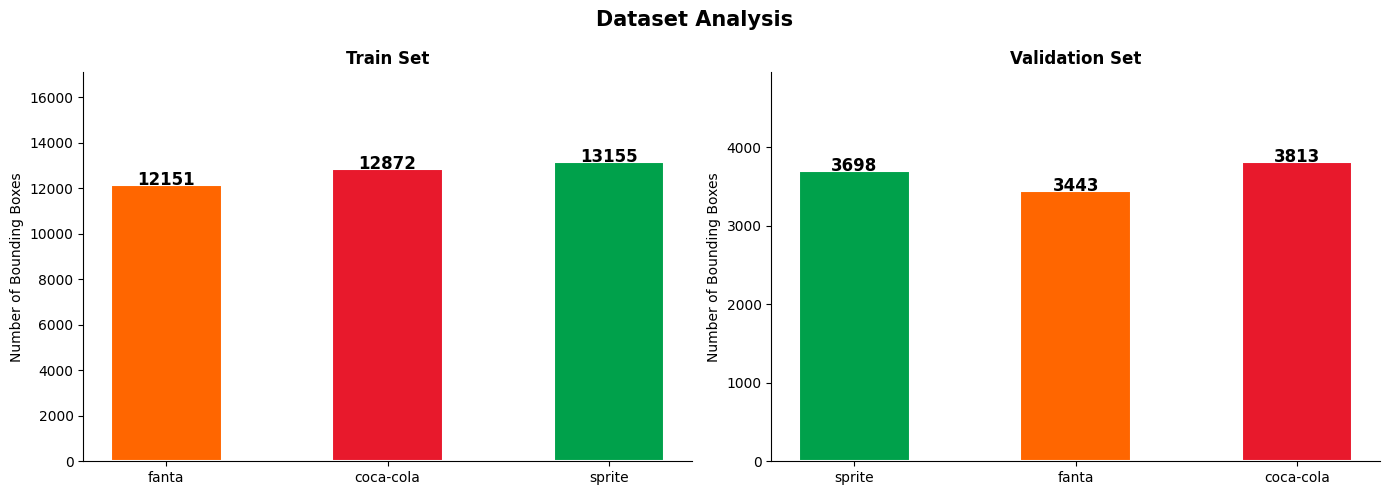

 Class Distribution Summary
   Class         Train  Valid
   --------------------------
   coca-cola     12872   3813
   fanta         12151   3443
   sprite        13155   3698


In [3]:
def count_labels(split):
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    counts  = defaultdict(int)
    if not os.path.exists(lbl_dir):
        return counts
    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    counts[CLASS_NAMES[cls_id]] += 1
    return counts
train_counts = count_labels('train')
val_counts   = count_labels('valid')

# Plot 1: Class Distribution
COLORS_MAP = {'coca-cola': '#E8192C', 'sprite': '#00A14B', 'fanta': '#FF6600'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Analysis', fontsize=15, fontweight='bold')

for ax, (counts, title) in zip(axes, [(train_counts,'Train Set'), (val_counts,'Validation Set')]):
    names  = list(counts.keys())
    values = list(counts.values())
    colors = [COLORS_MAP.get(n,'#999') for n in names]
    bars   = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Bounding Boxes')
    ax.set_ylim(0, max(values)*1.3 if values else 10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(val), ha='center', fontweight='bold', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Class Distribution Summary")
print(f"   {'Class':<12} {'Train':>6} {'Valid':>6}")
print(f"   {'-'*26}")
for name in CLASS_NAMES:
    print(f"   {name:<12} {train_counts.get(name,0):>6} {val_counts.get(name,0):>6}")

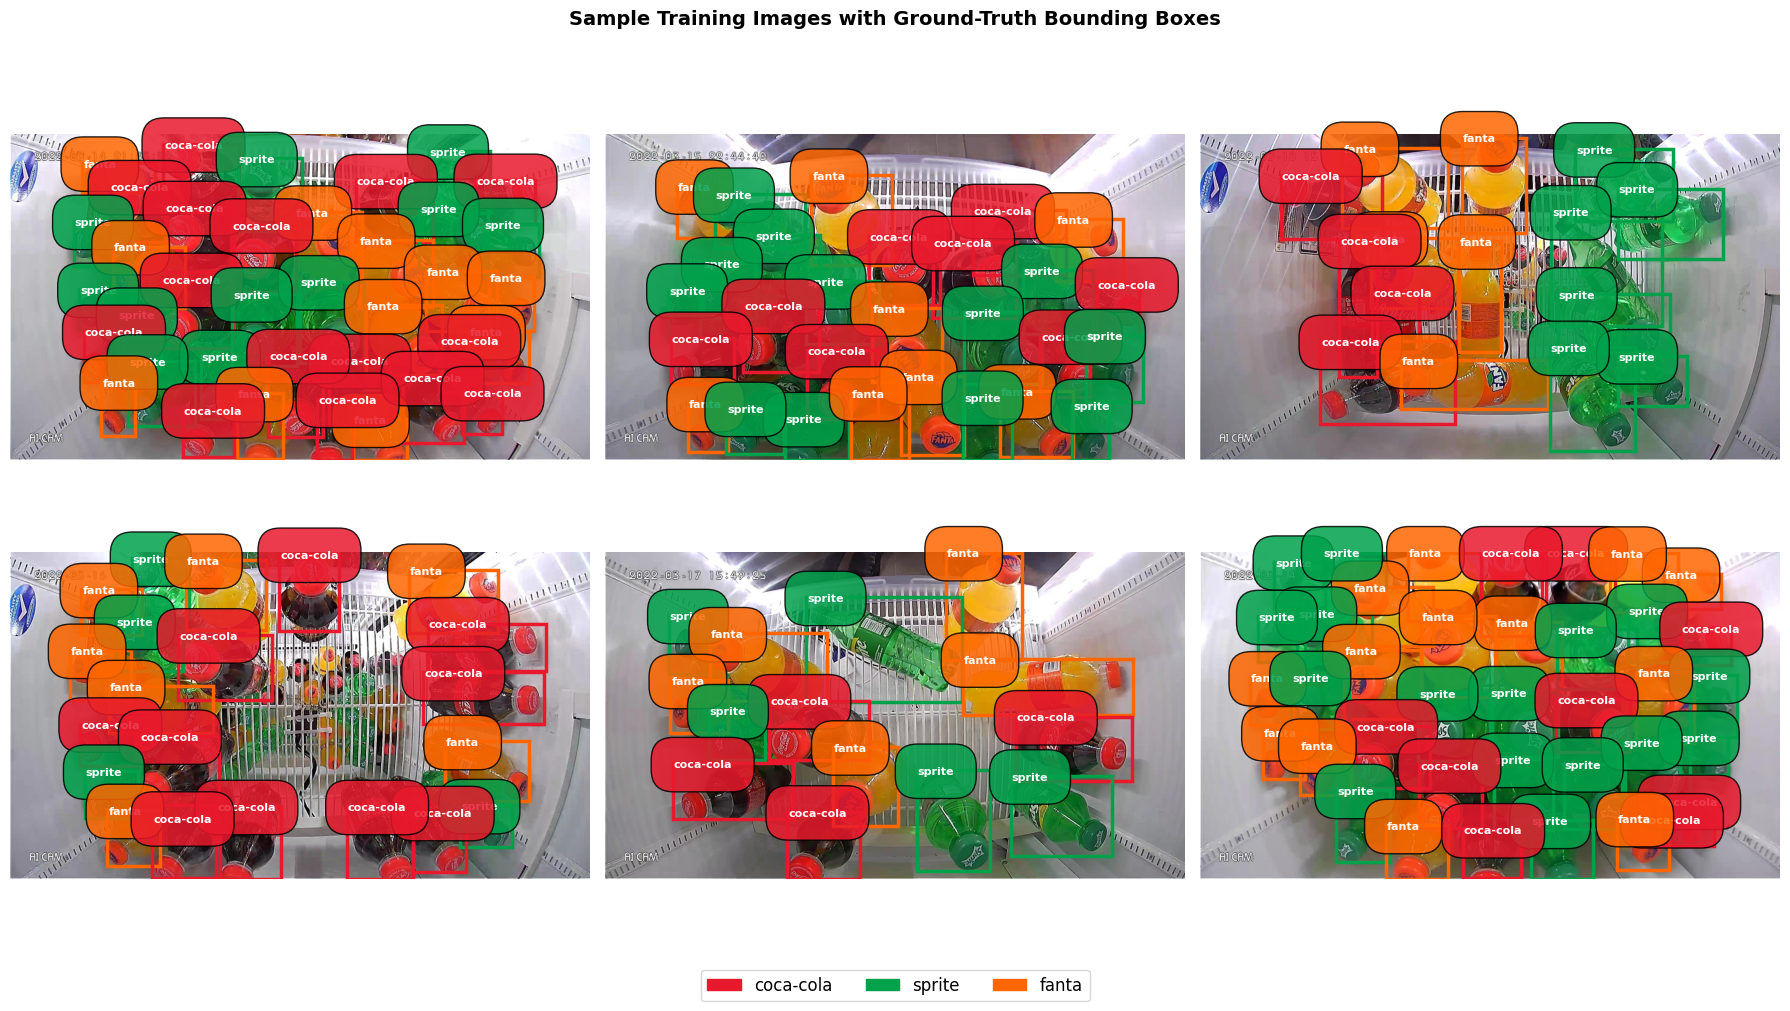

Sample images saved as 'sample_images_with_boxes.png'


In [4]:
#Visualise sample images with bounding boxes
def draw_yolo_boxes(ax, img_path, lbl_path):
    #Draw bounding boxes on an image given a YOLO-format label file.
    img  = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id       = int(parts[0])
                cx,cy,bw,bh  = map(float, parts[1:5])
                # Convert normalised → pixel coordinates
                x1 = (cx - bw/2) * W
                y1 = (cy - bh/2) * H
                pw, ph = bw * W, bh * H
                name   = CLASS_NAMES[cls_id]
                color  = COLORS_MAP.get(name, '#999')
                rect   = patches.Rectangle((x1,y1), pw, ph,
                                            linewidth=2.5, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1+3, y1+14, name, fontsize=8, color='white', fontweight='bold',
                        bbox=dict(facecolor=color, alpha=0.85, pad=2, boxstyle='round'))
    ax.axis('off')

# Pick 6 random training images
train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')
train_lbl_dir = os.path.join(DATASET_DIR, 'train', 'labels')
all_imgs      = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg','.png','.jpeg'))]
sample_imgs   = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sample Training Images with Ground-Truth Bounding Boxes', fontsize=14, fontweight='bold')
for ax, img_name in zip(axes.flatten(), sample_imgs):
    img_path = os.path.join(train_img_dir, img_name)
    lbl_name = Path(img_name).stem + '.txt'
    lbl_path = os.path.join(train_lbl_dir, lbl_name)
    draw_yolo_boxes(ax, img_path, lbl_path)

# Legend
handles = [patches.Patch(color=c, label=n) for n,c in COLORS_MAP.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
plt.tight_layout()
plt.savefig('sample_images_with_boxes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved as 'sample_images_with_boxes.png'")


## STEP 4 — Build the Model: ResNet50 + Detection Head





In [5]:
# 4A — Custom Dataset Loader
# PyTorch needs a Dataset class that tells it HOW to load each image
# and its corresponding labels. We write one that reads YOLO-format files.
class SodaBottleDataset(Dataset):

    def __init__(self, img_dir, lbl_dir, transform=None):
        self.img_dir   = img_dir
        self.lbl_dir   = lbl_dir
        self.transform = transform

        # Only keep images that also have a label file with at least 1 box
        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith(('.jpg', '.png', '.jpeg')):
                continue
            lbl_name = Path(fname).stem + '.txt'
            lbl_path = os.path.join(lbl_dir, lbl_name)
            if os.path.exists(lbl_path):
                boxes = self._parse_labels(lbl_path)
                if boxes:   # only include images that have at least one box
                    self.samples.append((fname, boxes))

        print(f"   Loaded {len(self.samples)} samples from {img_dir}")
    def _parse_labels(self, lbl_path):
        #Read all boxes from a YOLO .txt file. Returns list of (cls, cx, cy, bw, bh).
        boxes = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id       = int(parts[0])
                    cx,cy,bw,bh  = map(float, parts[1:5])
                    boxes.append((cls_id, cx, cy, bw, bh))
        return boxes
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, boxes = self.samples[idx]

        #Load image
        img_path = os.path.join(self.img_dir, fname)
        image    = np.array(Image.open(img_path).convert('RGB'))

        #Pick the largest bounding box (by area)
        largest = max(boxes, key=lambda b: b[3] * b[4])
        cls_id  = largest[0]
        bbox    = list(largest[1:5])   # [cx, cy, bw, bh]

        #Apply image transforms (resize, normalise, augment)
        if self.transform:
            augmented = self.transform(image=image)
            image     = augmented['image']   # returns a tensor
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0

        label = torch.tensor(cls_id,  dtype=torch.long)
        bbox  = torch.tensor(bbox,    dtype=torch.float32)

        return image, label, bbox

print(" SodaBottleDataset class defined")

 SodaBottleDataset class defined


For simplicity, when an image has multiple bottles we train on the LARGEST bounding box per image.

In [6]:
# 4B — Image Transforms / Augmentations
IMG_SIZE = 224   # ResNet50's native input size

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# TRAINING transforms — includes augmentation for variety
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),             # randomly flip image left/right
    A.ColorJitter(                        # randomly change brightness/contrast
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05, p=0.7),
    A.Rotate(limit=10, p=0.4),            # slight rotation (bottles can tilt)
    A.GaussNoise(var_limit=(5,25), p=0.3),# add slight noise
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),                         # convert numpy → pytorch tensor
])

# VALIDATION transforms — NO augmentation (only resize + normalise)
# We want to evaluate on clean images, not randomly modified ones
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Create Dataset objects
print("Creating datasets...")
train_dataset = SodaBottleDataset(
    img_dir   = os.path.join(DATASET_DIR, 'train', 'images'),
    lbl_dir   = os.path.join(DATASET_DIR, 'train', 'labels'),
    transform = train_transform
)

val_dataset = SodaBottleDataset(
    img_dir   = os.path.join(DATASET_DIR, 'valid', 'images'),
    lbl_dir   = os.path.join(DATASET_DIR, 'valid', 'labels'),
    transform = val_transform
)

# Create DataLoaders
BATCH_SIZE = 16   # process 16 images at once

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True       # speed boost for GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\nDataLoaders ready!")
print(f"   Train batches : {len(train_loader)} × {BATCH_SIZE} images")
print(f"   Val batches   : {len(val_loader)} × {BATCH_SIZE} images")

Creating datasets...
   Loaded 1574 samples from /content/soda-bottles-haga-1/train/images
   Loaded 449 samples from /content/soda-bottles-haga-1/valid/images

DataLoaders ready!
   Train batches : 99 × 16 images
   Val batches   : 29 × 16 images


In [7]:
# 4C — Build the ResNet50 + Detection Head Model
class ResNet50DetectionModel(nn.Module):

    def __init__(self, num_classes=3, freeze_backbone=True):
        super().__init__()

        #Load ResNet50 with ImageNet pre-trained weights
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        #Optionally freeze backbone weights
        #Frozen= those layers won't update during training Phase 1
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("Backbone FROZEN — only detection head will train")
        else:
            print("Backbone UNFROZEN — full model will train")

        FEATURE_DIM = 2048
        HIDDEN_DIM  = 512

        # Classification Head
        # Answers: which brand is this?
        # CrossEntropyLoss is applied to this output during training
        self.cls_head = nn.Sequential(
            nn.Linear(FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(p=0.4),   # randomly zero 40% of neurons, this prevents overfitting
            nn.Linear(HIDDEN_DIM, num_classes)
            # No softmax here — CrossEntropyLoss handles that internally
        )

        # Bounding Box Head
        self.box_head = nn.Sequential(
            nn.Linear(FEATURE_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(HIDDEN_DIM, 4),
            nn.Sigmoid()   # constrains output to [0,1]
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        cls_logits = self.cls_head(features)
        bbox_preds = self.box_head(features)
        return cls_logits, bbox_preds

    def unfreeze_last_layers(self, num_layers=2):
        children = list(self.backbone.children())
        for child in children[-num_layers:]:
            for param in child.parameters():
                param.requires_grad = True
        unfrozen = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total    = sum(p.numel() for p in self.parameters())
        print(f"   Unfrozen last {num_layers} backbone layers")
        print(f"   Trainable params: {unfrozen:,} / {total:,} ({100*unfrozen/total:.1f}%)")


# Instantiate model — Phase 1: frozen backbone
print("  Building ResNet50 Detection Model...")
model = ResNet50DetectionModel(num_classes=NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Parameter count
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model Summary")
print(f"   Total parameters     : {total_params:>12,}")
print(f"   Trainable (Phase 1)  : {trainable_params:>12,}  ({100*trainable_params/total_params:.1f}%)")
print(f"   Frozen (backbone)    : {total_params-trainable_params:>12,}")
print(f"\n Model moved to: {DEVICE}")

  Building ResNet50 Detection Model...
Backbone FROZEN — only detection head will train

 Model Summary
   Total parameters     :   25,609,799
   Trainable (Phase 1)  :    2,101,767  (8.2%)
   Frozen (backbone)    :   23,508,032

 Model moved to: cuda



## STEP 5 — Train the Model





In [8]:
# 5A — Loss Functions and Helper Utilities
def compute_iou(pred_boxes, gt_boxes):

    # Convert [cx, cy, w, h] → [x1, y1, x2, y2]
    def to_xyxy(b):
        return torch.stack([
            b[:,0] - b[:,2]/2,   # x1
            b[:,1] - b[:,3]/2,   # y1
            b[:,0] + b[:,2]/2,   # x2
            b[:,1] + b[:,3]/2    # y2
        ], dim=1)

    pred = to_xyxy(pred_boxes)
    gt   = to_xyxy(gt_boxes)

    # Intersection rectangle
    x1 = torch.max(pred[:,0], gt[:,0])
    y1 = torch.max(pred[:,1], gt[:,1])
    x2 = torch.min(pred[:,2], gt[:,2])
    y2 = torch.min(pred[:,3], gt[:,3])

    inter = torch.clamp(x2-x1, min=0) * torch.clamp(y2-y1, min=0)
    area_pred = (pred[:,2]-pred[:,0]) * (pred[:,3]-pred[:,1])
    area_gt   = (gt[:,2]  -gt[:,0])   * (gt[:,3]  -gt[:,1])
    union = area_pred + area_gt - inter + 1e-6   # add epsilon to avoid div-by-zero

    return (inter / union).mean().item()


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum, self.count = 0.0, 0
    def update(self, val, n=1):
        self.sum   += val * n
        self.count += n
    @property
    def avg(self):
        return self.sum / self.count if self.count else 0.0


print("Loss functions and helpers defined")

Loss functions and helpers defined


In [9]:
# 5B — Training and Validation Loop Function
cls_criterion  = nn.CrossEntropyLoss()   # for classification
bbox_criterion = nn.SmoothL1Loss()       # for bounding box regression
BBOX_WEIGHT    = 5.0                     # how much to weight bbox loss vs cls loss


def train_one_epoch(model, loader, optimizer, epoch):
    model.train()   # sets model to training mode
    loss_meter = AverageMeter()
    cls_meter  = AverageMeter()
    box_meter  = AverageMeter()
    acc_meter  = AverageMeter()
    iou_meter  = AverageMeter()
    for batch_idx, (images, labels, bboxes) in enumerate(loader):
        images = images.to(DEVICE)    # move data to GPU
        labels = labels.to(DEVICE)
        bboxes = bboxes.to(DEVICE)

        # Forward pass
        # Run the image through the model to get predictions
        cls_logits, bbox_preds = model(images)

        # Compute losses
        cls_loss  = cls_criterion(cls_logits, labels)
        bbox_loss = bbox_criterion(bbox_preds, bboxes)
        total_loss = cls_loss + BBOX_WEIGHT * bbox_loss

        # Backward pass
        optimizer.zero_grad()    # clear gradients from previous batch
        total_loss.backward()    # compute new gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
        optimizer.step()         # update weights

        # Track metrics
        n = images.size(0)
        preds = cls_logits.argmax(dim=1)
        acc   = (preds == labels).float().mean().item()
        iou   = compute_iou(bbox_preds.detach(), bboxes)

        loss_meter.update(total_loss.item(), n)
        cls_meter.update(cls_loss.item(), n)
        box_meter.update(bbox_loss.item(), n)
        acc_meter.update(acc, n)
        iou_meter.update(iou, n)

        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(loader):
            print(f"  Epoch {epoch} [{batch_idx+1:>3}/{len(loader)}]  "
                  f"Loss: {loss_meter.avg:.4f}  "
                  f"Cls: {cls_meter.avg:.4f}  "
                  f"Box: {box_meter.avg:.4f}  "
                  f"Acc: {acc_meter.avg:.2%}  "
                  f"IoU: {iou_meter.avg:.3f}")

    return {"loss": loss_meter.avg, "cls_loss": cls_meter.avg,
            "box_loss": box_meter.avg, "acc": acc_meter.avg, "iou": iou_meter.avg}

@torch.no_grad()  # disables gradient computation — saves memory during evaluation
def validate(model, loader):
    model.eval()   # sets model to eval mode (disables dropout)

    loss_meter = AverageMeter()
    acc_meter  = AverageMeter()
    iou_meter  = AverageMeter()

    all_preds, all_labels = [], []

    for images, labels, bboxes in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        bboxes = bboxes.to(DEVICE)

        cls_logits, bbox_preds = model(images)

        cls_loss  = cls_criterion(cls_logits, labels)
        bbox_loss = bbox_criterion(bbox_preds, bboxes)
        total_loss = cls_loss + BBOX_WEIGHT * bbox_loss

        n = images.size(0)
        preds = cls_logits.argmax(dim=1)
        acc   = (preds == labels).float().mean().item()
        iou   = compute_iou(bbox_preds, bboxes)

        loss_meter.update(total_loss.item(), n)
        acc_meter.update(acc, n)
        iou_meter.update(iou, n)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {"loss": loss_meter.avg, "acc": acc_meter.avg,
            "iou": iou_meter.avg, "preds": all_preds, "labels": all_labels}


print("Training and validation functions defined")

Training and validation functions defined


In [10]:
# 5C — PHASE 1 TRAINING: Frozen Backbone (Epochs 1-10)
from google.colab import files
PHASE1_EPOCHS = 10
LR_PHASE1     = 1e-3

# Only optimise parameters that have requires_grad=True
# (backbone is frozen, so only head params are included)
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=1e-4
)

# reduce LR by half if val loss doesn't improve for 3 epochs
scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', patience=3, factor=0.5
)

# Storage for history
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'train_iou':[], 'val_iou':[], 'phase_boundary': None}

best_val_loss  = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

print("PHASE 1 TRAINING — Frozen Backbone")
print(f"   Epochs: {PHASE1_EPOCHS}   LR: {LR_PHASE1}   Batch: {BATCH_SIZE}")
print("="*70)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    print(f"\nEpoch {epoch}/{PHASE1_EPOCHS}")

    train_metrics = train_one_epoch(model, train_loader, optimizer_p1, epoch)
    val_metrics   = validate(model, val_loader)

    scheduler_p1.step(val_metrics['loss'])
    # Save best model
    if val_metrics['loss'] < best_val_loss:
        best_val_loss  = val_metrics['loss']
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'best_model.pt')
        print(f"    New best model saved! Val Loss: {best_val_loss:.4f}")

    # Record history
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_iou'].append(train_metrics['iou'])
    history['val_iou'].append(val_metrics['iou'])

    elapsed = time.time() - t0
    print(f"   ─── Epoch {epoch} Summary ─── ({elapsed:.0f}s)")
    print(f"   Train → Loss: {train_metrics['loss']:.4f}  Acc: {train_metrics['acc']:.2%}  IoU: {train_metrics['iou']:.3f}")
    print(f"   Val   → Loss: {val_metrics['loss']:.4f}  Acc: {val_metrics['acc']:.2%}  IoU: {val_metrics['iou']:.3f}")

history['phase_boundary'] = PHASE1_EPOCHS
print(f"\n✅ Phase 1 complete! Best val loss: {best_val_loss:.4f}")
files.download('best_model.pt')
print("📥 Phase 1 → best_model.pt downloaded!")

PHASE 1 TRAINING — Frozen Backbone
   Epochs: 10   LR: 0.001   Batch: 16

Epoch 1/10
  Epoch 1 [ 10/99]  Loss: 1.2213  Cls: 1.1349  Box: 0.0173  Acc: 38.75%  IoU: 0.037
  Epoch 1 [ 20/99]  Loss: 1.2044  Cls: 1.1261  Box: 0.0157  Acc: 40.00%  IoU: 0.033
  Epoch 1 [ 30/99]  Loss: 1.2087  Cls: 1.1363  Box: 0.0145  Acc: 37.29%  IoU: 0.047
  Epoch 1 [ 40/99]  Loss: 1.1901  Cls: 1.1193  Box: 0.0142  Acc: 38.12%  IoU: 0.051
  Epoch 1 [ 50/99]  Loss: 1.1992  Cls: 1.1303  Box: 0.0138  Acc: 37.62%  IoU: 0.052
  Epoch 1 [ 60/99]  Loss: 1.2003  Cls: 1.1328  Box: 0.0135  Acc: 37.92%  IoU: 0.054
  Epoch 1 [ 70/99]  Loss: 1.1995  Cls: 1.1322  Box: 0.0135  Acc: 37.50%  IoU: 0.053
  Epoch 1 [ 80/99]  Loss: 1.1940  Cls: 1.1274  Box: 0.0133  Acc: 37.27%  IoU: 0.054
  Epoch 1 [ 90/99]  Loss: 1.1897  Cls: 1.1239  Box: 0.0132  Acc: 37.57%  IoU: 0.055
  Epoch 1 [ 99/99]  Loss: 1.1872  Cls: 1.1220  Box: 0.0130  Acc: 37.61%  IoU: 0.055
    New best model saved! Val Loss: 1.1346
   ─── Epoch 1 Summary ─── (45s)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Phase 1 → best_model.pt downloaded!


In Phase 1:                                                            
-> Only the new cls_head and box_head weights update                 
-> ResNet50 backbone weights stay completely fixed                     
-> We use a moderate learning rate (1e-3)                              
-> Adam optimizer adapts the learning rate per-parameter automatically

In [11]:
# 5D — PHASE 2 TRAINING: Unfreeze Last Layers (Epochs 11-30)
PHASE2_EPOCHS  = 20
LR_PHASE2      = 1e-4    # 10× smaller than Phase 1

# Unfreeze last 2 backbone layer groups
print(" Unfreezing last 2 ResNet50 layer blocks for Phase 2...")
model.unfreeze_last_layers(num_layers=2)

# Use different learning rates for backbone vs head
optimizer_p2 = optim.Adam([
    {'params': model.backbone.parameters(), 'lr': LR_PHASE2 * 0.1},  # backbone: very small LR
    {'params': model.cls_head.parameters(), 'lr': LR_PHASE2},         # cls head: normal small LR
    {'params': model.box_head.parameters(), 'lr': LR_PHASE2},         # box head: normal small LR
], weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6
)

print(f"\nPHASE 2 TRAINING — Partial Unfreeze + Full Fine-Tuning")
print(f"   Epochs: {PHASE2_EPOCHS}   Backbone LR: {LR_PHASE2*0.1}   Head LR: {LR_PHASE2}")
print("="*70)

for epoch in range(PHASE1_EPOCHS + 1, PHASE1_EPOCHS + PHASE2_EPOCHS + 1):
    t0 = time.time()
    ep_display = epoch - PHASE1_EPOCHS
    print(f"\n Phase 2 — Epoch {ep_display}/{PHASE2_EPOCHS} (Global: {epoch})")

    train_metrics = train_one_epoch(model, train_loader, optimizer_p2, epoch)
    val_metrics   = validate(model, val_loader)

    scheduler_p2.step()

    if val_metrics['loss'] < best_val_loss:
        best_val_loss  = val_metrics['loss']
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'best_model.pt')
        print(f"   New best model saved! Val Loss: {best_val_loss:.4f}")

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_iou'].append(train_metrics['iou'])
    history['val_iou'].append(val_metrics['iou'])

    elapsed = time.time() - t0
    print(f"   ─── Epoch {ep_display} Summary ─── ({elapsed:.0f}s)")
    print(f"   Train → Loss: {train_metrics['loss']:.4f}  Acc: {train_metrics['acc']:.2%}  IoU: {train_metrics['iou']:.3f}")
    print(f"   Val   → Loss: {val_metrics['loss']:.4f}  Acc: {val_metrics['acc']:.2%}  IoU: {val_metrics['iou']:.3f}")

print(f"\n Training Complete! Best Val Loss: {best_val_loss:.4f}")
files.download('best_model.pt')
print(" Phase 2 → best_model.pt downloaded!")

 Unfreezing last 2 ResNet50 layer blocks for Phase 2...
   Unfrozen last 2 backbone layers
   Trainable params: 17,066,503 / 25,609,799 (66.6%)

PHASE 2 TRAINING — Partial Unfreeze + Full Fine-Tuning
   Epochs: 20   Backbone LR: 1e-05   Head LR: 0.0001

 Phase 2 — Epoch 1/20 (Global: 11)
  Epoch 11 [ 10/99]  Loss: 1.1400  Cls: 1.0826  Box: 0.0115  Acc: 41.88%  IoU: 0.067
  Epoch 11 [ 20/99]  Loss: 1.0917  Cls: 1.0370  Box: 0.0109  Acc: 44.38%  IoU: 0.059
  Epoch 11 [ 30/99]  Loss: 1.0878  Cls: 1.0334  Box: 0.0109  Acc: 45.83%  IoU: 0.059
  Epoch 11 [ 40/99]  Loss: 1.0786  Cls: 1.0237  Box: 0.0110  Acc: 47.66%  IoU: 0.062
  Epoch 11 [ 50/99]  Loss: 1.0758  Cls: 1.0209  Box: 0.0110  Acc: 47.88%  IoU: 0.063
  Epoch 11 [ 60/99]  Loss: 1.0766  Cls: 1.0217  Box: 0.0110  Acc: 47.92%  IoU: 0.064
  Epoch 11 [ 70/99]  Loss: 1.0708  Cls: 1.0156  Box: 0.0110  Acc: 49.29%  IoU: 0.062
  Epoch 11 [ 80/99]  Loss: 1.0676  Cls: 1.0125  Box: 0.0110  Acc: 49.14%  IoU: 0.062
  Epoch 11 [ 90/99]  Loss: 1.07

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Phase 2 → best_model.pt downloaded!


In this phase, we unfreeze the last 2 ResNet blocks so they can adapt
their deep features to soda bottle recognition.
ALso, used a much smaller learning rate (10x smaller)
to avoid overwriting the pre-trained weights aggressively.


## STEP 6 — Evaluate the Model

Best model weights loaded


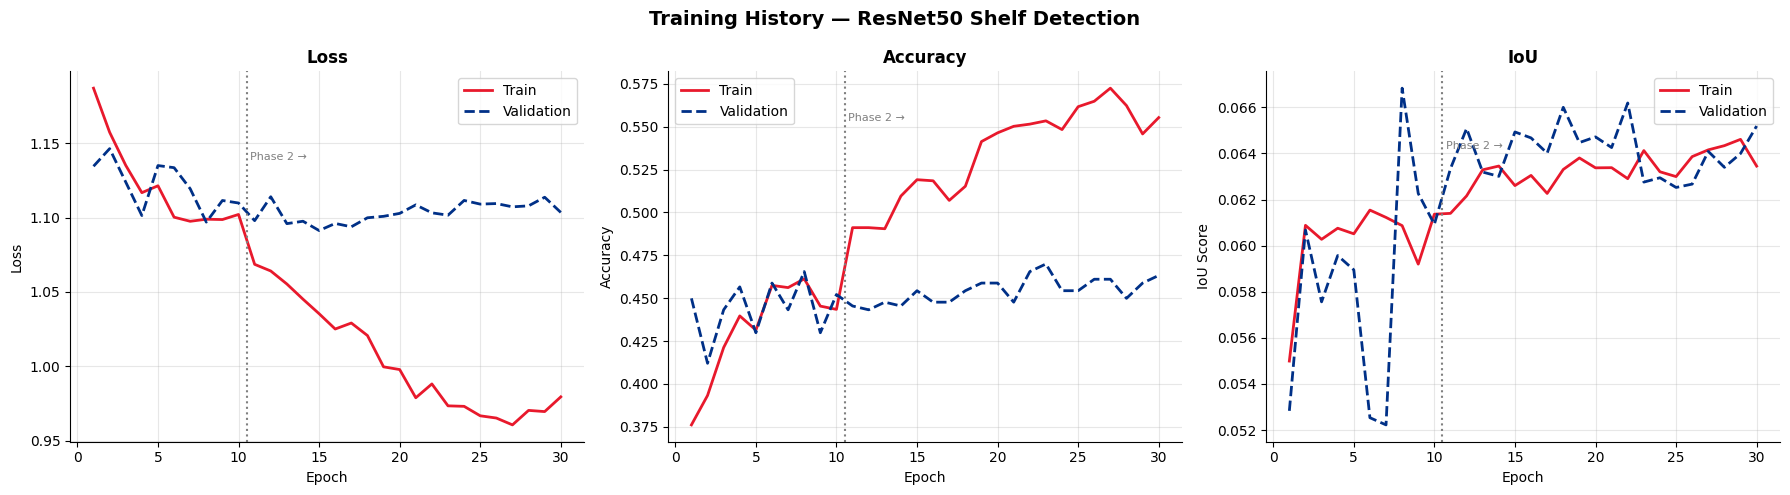

Training curves saved as 'training_curves.png'


In [12]:
# Load best model weights
model.load_state_dict(torch.load('best_model.pt'))
print("Best model weights loaded")
# Training Curves
epochs   = range(1, len(history['train_loss']) + 1)
boundary = history['phase_boundary']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — ResNet50 Shelf Detection', fontsize=14, fontweight='bold')

TRAIN_COLOR = '#E8192C'
VAL_COLOR   = '#003087'
for ax, (train_key, val_key, title, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss',     'Loss'),
    ('train_acc',  'val_acc',  'Accuracy', 'Accuracy'),
    ('train_iou',  'val_iou',  'IoU',      'IoU Score'),
]):
    ax.plot(epochs, history[train_key], color=TRAIN_COLOR, lw=2, label='Train')
    ax.plot(epochs, history[val_key],   color=VAL_COLOR,   lw=2, label='Validation', linestyle='--')

    if boundary:
        ax.axvline(x=boundary + 0.5, color='gray', linestyle=':', linewidth=1.5)
        ax.text(boundary + 0.7, ax.get_ylim()[1]*0.95, 'Phase 2 →',
                fontsize=8, color='gray')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as 'training_curves.png'")

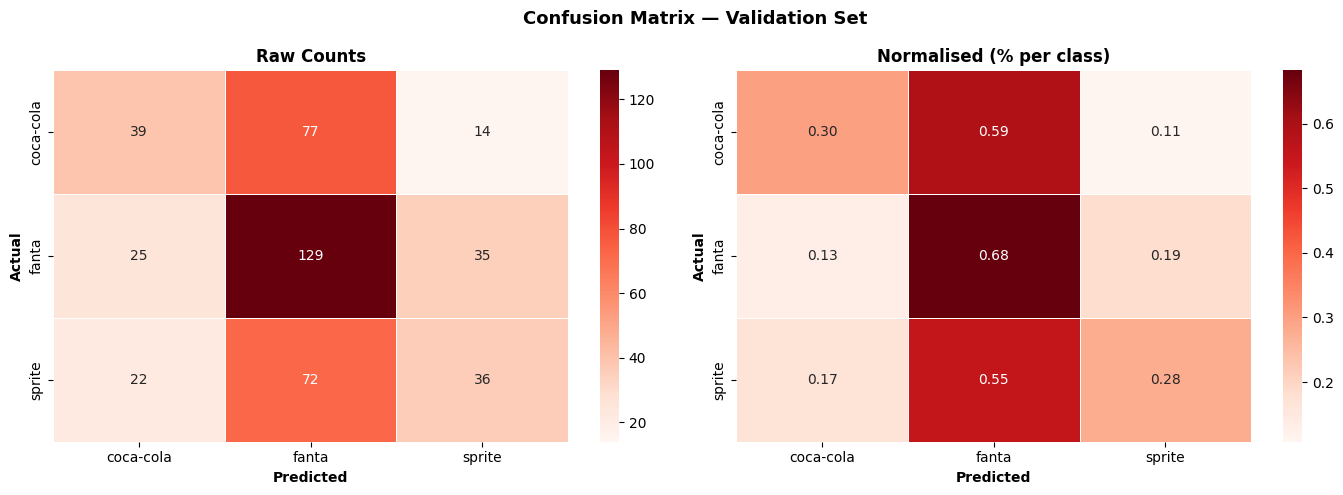


 Final Evaluation Results
   Overall Accuracy : 45.43%
   Average IoU      : 0.065

   Class         Correct    Total      Acc
   ----------------------------------------
   coca-cola          39      130   30.00%
   fanta             129      189   68.25%
   sprite             36      130   27.69%


In [13]:
# Confusion Matrix
# A confusion matrix shows where the model gets confused:
# - Rows = actual class
# - Columns = predicted class
# - Diagonal = correct predictions

final_val = validate(model, val_loader)
all_preds  = np.array(final_val['preds'])
all_labels = np.array(final_val['labels'])

# Build confusion matrix manually
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm[true][pred] += 1

# Normalise by row (actual class) to get percentages
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')

for ax, (data, fmt, title) in zip(axes, [
    (cm,      'd',    'Raw Counts'),
    (cm_norm, '.2f',  'Normalised (% per class)'),
]):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Reds', linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual',    fontweight='bold')
    ax.set_title(title,        fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\n Final Evaluation Results")
print("="*50)
print(f"   Overall Accuracy : {final_val['acc']:.2%}")
print(f"   Average IoU      : {final_val['iou']:.3f}")
print()
print(f"   {'Class':<12} {'Correct':>8} {'Total':>8} {'Acc':>8}")
print(f"   {'-'*40}")
for i, name in enumerate(CLASS_NAMES):
    correct = cm[i, i]
    total   = cm[i].sum()
    acc     = correct / total if total > 0 else 0
    print(f"   {name:<12} {correct:>8} {total:>8} {acc:>8.2%}")
print("="*50)


## STEP 7 — Run Inference on New Shelf Images


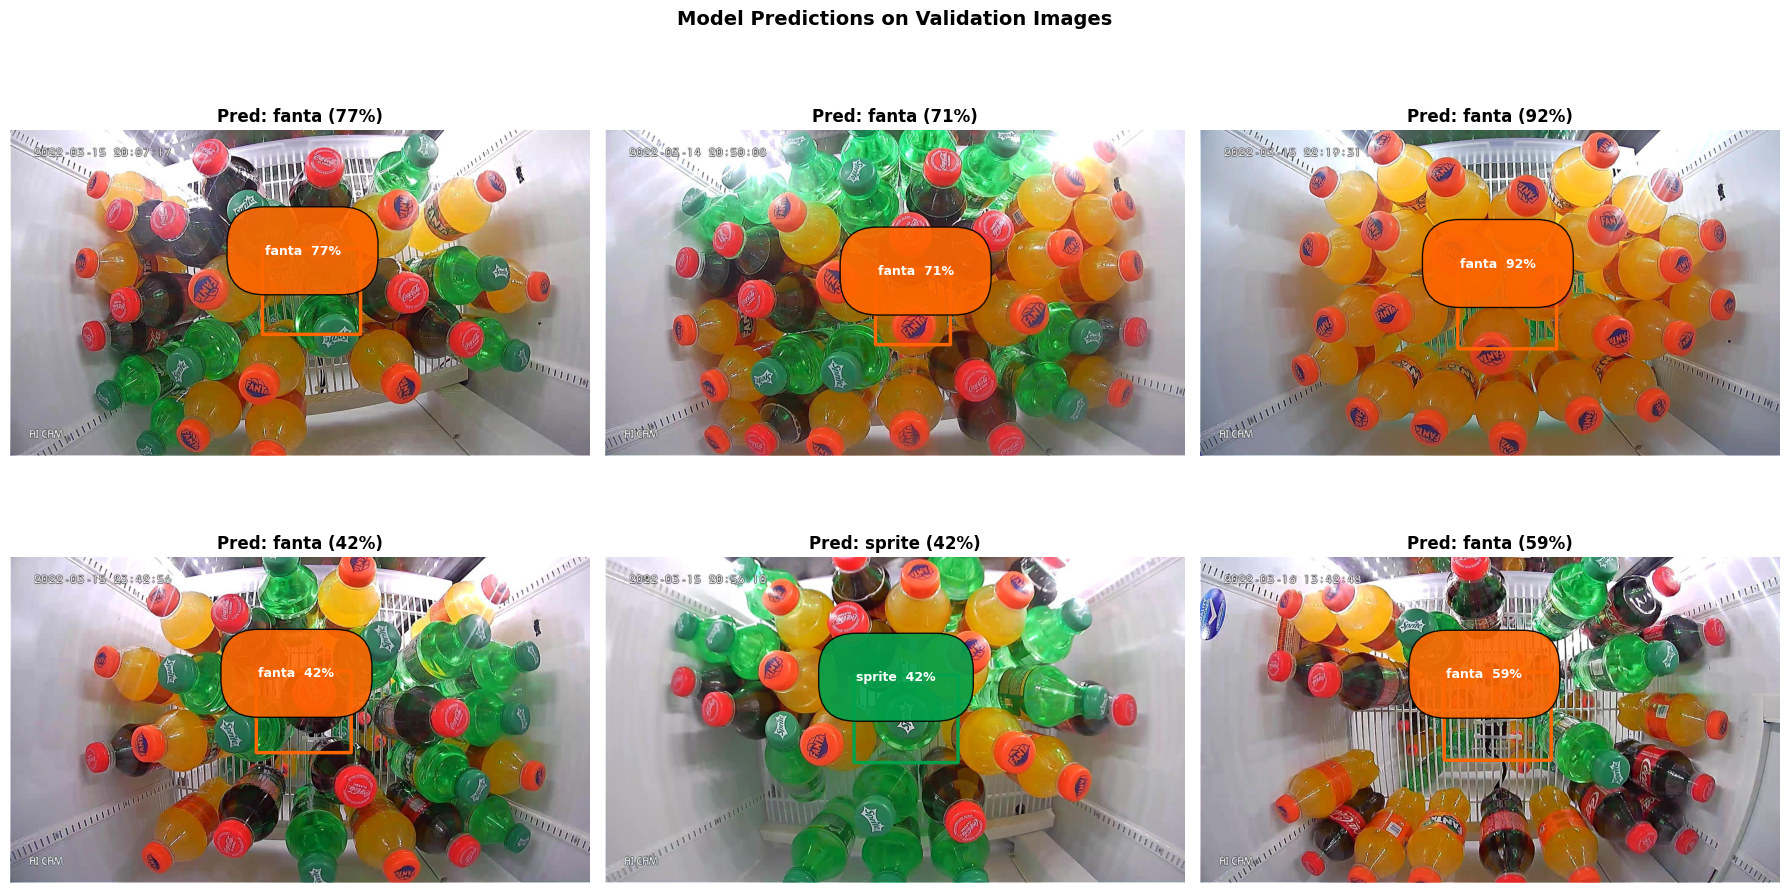

Inference results saved as 'inference_results.png'


In [14]:
def predict_single_image(image_path, model, threshold=0.5):

    model.eval()
    # Load and preprocess image
    img     = np.array(Image.open(image_path).convert('RGB'))
    H_orig, W_orig = img.shape[:2]

    augmented = val_transform(image=img)
    tensor    = augmented['image'].unsqueeze(0).to(DEVICE)   # add batch dimension

    with torch.no_grad():
        cls_logits, bbox_preds = model(tensor)

    # Classification result
    probs      = F.softmax(cls_logits, dim=1)[0]
    conf, cls_id = probs.max(0)
    class_name   = CLASS_NAMES[cls_id.item()]
    confidence   = conf.item()

    # Bounding box (normalised → pixel coords)
    cx, cy, bw, bh = bbox_preds[0].cpu().numpy()
    x1 = int((cx - bw/2) * W_orig)
    y1 = int((cy - bh/2) * H_orig)
    x2 = int((cx + bw/2) * W_orig)
    y2 = int((cy + bh/2) * H_orig)

    return {"class": class_name, "confidence": confidence,
            "bbox_pixel": (x1, y1, x2, y2),
            "bbox_norm":  (cx, cy, bw, bh),
            "all_probs":  {CLASS_NAMES[i]: probs[i].item() for i in range(NUM_CLASSES)}}


def visualise_prediction(image_path, result, ax):
    img  = Image.open(image_path).convert('RGB')
    ax.imshow(img)

    x1,y1,x2,y2 = result['bbox_pixel']
    color = COLORS_MAP.get(result['class'], '#999')

    rect = patches.FancyBboxPatch((x1,y1), x2-x1, y2-y1,
                                   boxstyle='round,pad=3', linewidth=2.5,
                                   edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1+4, y1+16,
            f"{result['class']}  {result['confidence']:.0%}",
            fontsize=9, color='white', fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.9, pad=3, boxstyle='round'))
    ax.axis('off')
    ax.set_title(f"Pred: {result['class']} ({result['confidence']:.0%})",
                  fontweight='bold')


# Run on 6 validation images
val_img_dir = os.path.join(DATASET_DIR, 'valid', 'images')
val_imgs    = [f for f in os.listdir(val_img_dir) if f.endswith(('.jpg','.png','.jpeg'))]
sample_test = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Predictions on Validation Images', fontsize=14, fontweight='bold')

for ax, img_name in zip(axes.flatten(), sample_test):
    img_path = os.path.join(val_img_dir, img_name)
    result   = predict_single_image(img_path, model)
    visualise_prediction(img_path, result, ax)

plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Inference results saved as 'inference_results.png'")


## STEP 8 — Shelf Business Metrics



═══════════════════════════════════════════════════════
     SHELF ANALYSIS REPORT
═══════════════════════════════════════════════════════
   Image     : 01_20220317_135418_bmp_jpg.rf.5e0d7f2e38f55f4482f7f989eea8bd6b.jpg
   Detected  : sprite (48% confidence)

    Share of Shelf (SOS)
      coca-cola     70.7%  ██████████████
      fanta         29.3%  █████
      sprite         0.0%  

    On-Shelf Availability (OSA)
      coca-cola    ✅ Present
      fanta        ✅ Present
      sprite       ❌ Out-of-Stock

    Planogram : ✅ COMPLIANT
═══════════════════════════════════════════════════════


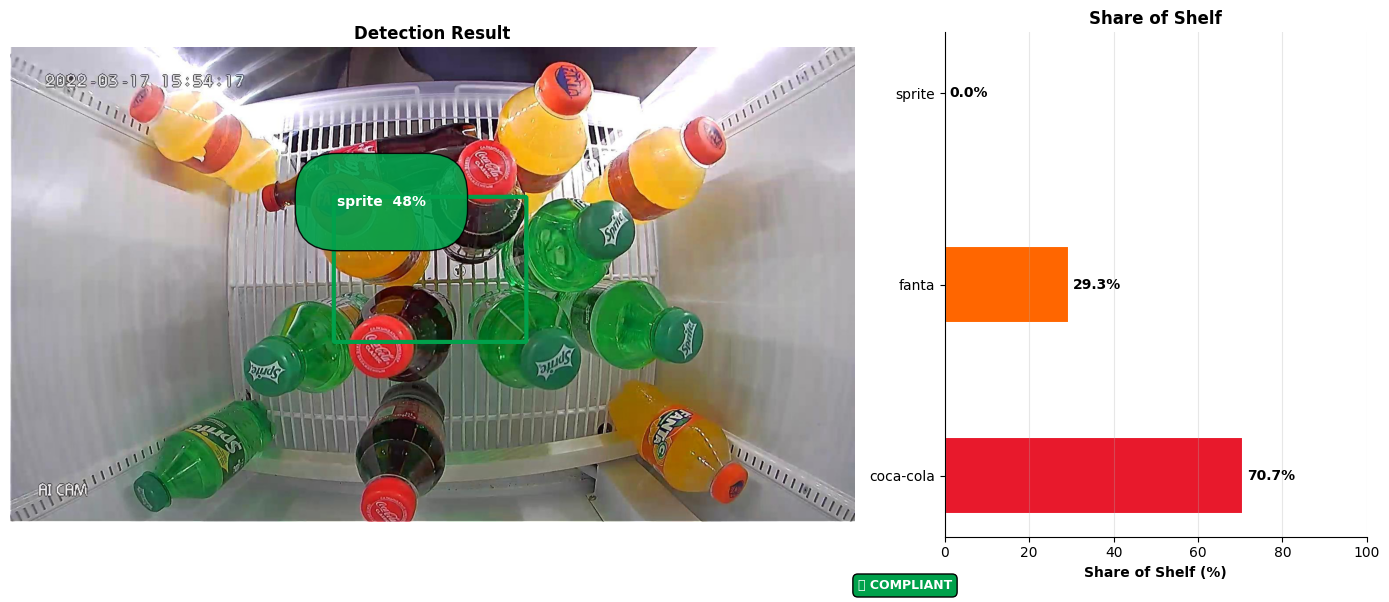

{'sos': {'coca-cola': np.float32(70.6649),
  'fanta': np.float32(29.3351),
  'sprite': np.float32(0.0)},
 'osa': {'coca-cola': '✅ Present',
  'fanta': '✅ Present',
  'sprite': '❌ Out-of-Stock'},
 'planogram': True}

In [15]:
def analyze_full_shelf(image_path, model, conf_threshold=0.50):

    result = predict_single_image(image_path, model)

    # Use bounding box area as proxy for shelf space
    cx, cy, bw, bh = result['bbox_norm']
    box_area = bw * bh

    brand_area  = defaultdict(float)
    brand_count = defaultdict(int)

    if result['confidence'] >= conf_threshold:
        brand_area[result['class']]  += box_area
        brand_count[result['class']] += 0

    # Also count lower-confidence detections from softmax
    for brand, prob in result['all_probs'].items():
        if prob > 0.10 and brand != result['class']:
            brand_area[brand]  += box_area * prob
            brand_count[brand] += 1 # detected but not primary

    total_area = sum(brand_area.values()) or 1.0
    sos = {name: (brand_area.get(name, 0) / total_area) * 100 for name in CLASS_NAMES}
    osa = {name: ("✅ Present" if brand_count.get(name, 0) > 0 else "❌ Out-of-Stock")
           for name in CLASS_NAMES}

    dominant     = max(sos, key=sos.get)
    planogram_ok = (dominant == 'coca-cola')

    # Print Report
    print("\n" + "═"*55)
    print("     SHELF ANALYSIS REPORT")
    print("═"*55)
    print(f"   Image     : {Path(image_path).name}")
    print(f"   Detected  : {result['class']} ({result['confidence']:.0%} confidence)")
    print()
    print("    Share of Shelf (SOS)")
    for name in sorted(sos, key=sos.get, reverse=True):
        bar = '█' * int(sos[name] / 5)
        print(f"      {name:<12} {sos[name]:5.1f}%  {bar}")
    print()
    print("    On-Shelf Availability (OSA)")
    for name in CLASS_NAMES:
        print(f"      {name:<12} {osa[name]}")
    print()
    badge = '✅ COMPLIANT' if planogram_ok else f'⚠️  NON-COMPLIANT ({dominant} dominates)'
    print(f"    Planogram : {badge}")
    print("═"*55)

    #Visualise
    fig, (ax_img, ax_sos) = plt.subplots(1, 2, figsize=(14, 6),
                                          gridspec_kw={'width_ratios': [2, 1]})
    img = Image.open(image_path)
    ax_img.imshow(img)
    x1,y1,x2,y2 = result['bbox_pixel']
    col = COLORS_MAP.get(result['class'], '#999')
    ax_img.add_patch(patches.FancyBboxPatch((x1,y1), x2-x1, y2-y1,
                     boxstyle='round,pad=3', lw=3, edgecolor=col, facecolor='none'))
    ax_img.text(x1+4, y1+18, f"{result['class']}  {result['confidence']:.0%}",
                fontsize=10, color='white', fontweight='bold',
                bbox=dict(facecolor=col, alpha=0.9, pad=3, boxstyle='round'))
    ax_img.axis('off')
    ax_img.set_title('Detection Result', fontweight='bold')

    bars = ax_sos.barh(CLASS_NAMES, [sos[n] for n in CLASS_NAMES],
                       color=[COLORS_MAP.get(n,'#999') for n in CLASS_NAMES],
                       height=0.4, edgecolor='white', lw=1.5)
    ax_sos.set_xlim(0, 100)
    ax_sos.set_xlabel('Share of Shelf (%)', fontweight='bold')
    ax_sos.set_title('Share of Shelf', fontweight='bold')
    for bar, n in zip(bars, CLASS_NAMES):
        ax_sos.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    f"{sos[n]:.1f}%", va='center', fontweight='bold')
    ax_sos.spines['top'].set_visible(False)
    ax_sos.spines['right'].set_visible(False)
    ax_sos.grid(axis='x', alpha=0.3)

    badge_col = '#00A14B' if planogram_ok else '#E8192C'
    fig.text(0.65, 0.01, badge, ha='center', fontsize=9, color='white',
             fontweight='bold',
             bbox=dict(facecolor=badge_col, pad=6, boxstyle='round,pad=0.4'))

    plt.tight_layout()
    plt.savefig('shelf_report.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {"sos": sos, "osa": osa, "planogram": planogram_ok}


# Test on one validation image
test_image = os.path.join(val_img_dir, val_imgs[0])
analyze_full_shelf(test_image, model)

---
# STEP 9 — Save & Export the Model

We save:
1. `best_model.pt` — full model weights (use for the Streamlit app)
2. `model_config.json` — class names and input size (so the app knows how to load)
3. All plots — include these in your project report

In [16]:
import json
from google.colab import files

config = {
    "class_names"  : CLASS_NAMES,
    "num_classes"  : NUM_CLASSES,
    "img_size"     : IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std" : IMAGENET_STD,
    "model_type"   : "ResNet50-DetectionHead",
    "best_val_loss": round(best_val_loss, 4),
    "final_val_acc": round(final_val['acc'], 4),
    "final_val_iou": round(final_val['iou'], 4),
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(" Model Configuration:")
print(json.dumps(config, indent=2))

# Final summary
print("\n" + "═"*55)
print("     TRAINING COMPLETE — FINAL SUMMARY")
print("═"*55)
print(f"   Best Validation Loss  : {best_val_loss:.4f}")
print(f"   Final Val Accuracy    : {final_val['acc']:.2%}")
print(f"   Final Val IoU         : {final_val['iou']:.3f}")
print()
print("   Files ready for download:")
print("    best_model.pt        ← use in Streamlit app")
print("    model_config.json    ← class names & settings")
print("    training_curves.png  ← include in report")
print("     confusion_matrix.png ← include in report")
print("     inference_results.png← include in report")
print("═"*55)

# Download all files
print("\n Downloading files...")
for fname in ['best_model.pt', 'model_config.json',
              'training_curves.png', 'confusion_matrix.png',
              'inference_results.png', 'shelf_report.png',
              'class_distribution.png', 'sample_images_with_boxes.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f"    {fname}")
    else:
        print(f"     {fname} not found (may not have been generated)")

 Model Configuration:
{
  "class_names": [
    "coca-cola",
    "fanta",
    "sprite"
  ],
  "num_classes": 3,
  "img_size": 224,
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ],
  "model_type": "ResNet50-DetectionHead",
  "best_val_loss": 1.0913,
  "final_val_acc": 0.4543,
  "final_val_iou": 0.0649
}

═══════════════════════════════════════════════════════
     TRAINING COMPLETE — FINAL SUMMARY
═══════════════════════════════════════════════════════
   Best Validation Loss  : 1.0913
   Final Val Accuracy    : 45.43%
   Final Val IoU         : 0.065

   Files ready for download:
    best_model.pt        ← use in Streamlit app
    model_config.json    ← class names & settings
    training_curves.png  ← include in report
     confusion_matrix.png ← include in report
     inference_results.png← include in report
═══════════════════════════════════════════════════════



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    best_model.pt


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

    class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    sample_images_with_boxes.png


---
## 📖 Summary: What Each Part Did

| Component | Role | Key Concept |
|-----------|------|-------------|
| **ResNet50 Backbone** | Extracts image features | Transfer Learning — pre-trained on ImageNet |
| **Global Avg Pooling** | Compresses 7×7 feature map → 1 vector | Dimensionality reduction |
| **Classification Head** | Predicts brand (Coca-Cola/Sprite/Fanta) | CrossEntropyLoss |
| **Bounding Box Head** | Predicts bottle location [cx,cy,bw,bh] | SmoothL1Loss + Sigmoid |
| **Phase 1 Training** | Trains only the new head (frozen backbone) | Warm-up / Feature extraction |
| **Phase 2 Training** | Unfreezes last ResNet blocks | Fine-tuning at low LR |
| **SOS / OSA / Planogram** | Business-level shelf metrics | Converts detections → insights |

## 🚀 Next Steps

1. **Improve detection**: integrate a Region Proposal Network (RPN) to detect ALL bottles per image simultaneously
2. **More data**: add more shelf images via Roboflow and re-train
3. **Streamlit app**: load `best_model.pt` into the UI (see `streamlit_app.py`)

---
*Project: Retail Shelf AI · ResNet50 Fine-Tuning · Coca-Cola / Sprite / Fanta*